In [1]:
from google.colab import files
files.upload()  # Upload your .zip and CSV file (e.g. goemotions_300_cleaned.csv)


Saving goemotions_supported_only.csv to goemotions_supported_only.csv


{'goemotions_supported_only.csv': b'text,primary_emotion\nLiterally everywhere. There\'s nothing especially Texan about any of this. I heard all of this in freaking SCONSIN.,disappointment\n"[NAME] and [NAME] may be stronger, but [NAME] just gone mad. She\'s lost the plot for sure.",neutral\nIk I\xe2\x80\x99m crying rn,sadness\n"He was cut yesterday, unfortunately",neutral\n"Nice, I saw them during the Demo and was pretty impressed ",amusement\nFunny you ask,amusement\nMinus the eyebrows I personally think it\xe2\x80\x99s an attractive look. But the fucking eyebrows ruin it all.,admiration\n[NAME] is 16 and [NAME] is 19... But she\'s looks 16 as [NAME] 0.0,neutral\nJ E S U S C H R I S T those eyes,neutral\nmy heart...,neutral\n"Okay, gotcha. Does your wife have a lot of stress and anxiety from her job, or just in general?",neutral\nFinally a whole season and 3 jornadas too late.,disappointment\n*pounces on you* uwu you\xe2\x80\x99re so warm,surprise\n"Higher ranking officer? Also, I\'m

In [3]:
from google.colab import files

# Upload the model zip and the new test CSV
uploaded = files.upload()

Saving fine-tuned-goemotions.zip to fine-tuned-goemotions.zip


Device set to use cuda:0
Device set to use cuda:0


1. neutral
2. neutral
3. neutral
4. neutral
5. admiration
6. neutral
7. admiration
8. neutral
9. neutral
10. neutral
11. neutral
12. neutral
13. neutral
14. curiosity
15. excitement
16. neutral
17. neutral
18. neutral
19. approval
20. neutral
21. neutral
22. admiration
23. approval
24. neutral
25. approval
26. neutral
27. neutral
28. neutral
29. neutral
30. amusement
31. gratitude
32. admiration
33. neutral
34. disapproval
35. neutral
36. admiration
37. neutral
38. neutral
39. admiration
40. neutral
41. neutral
42. anger
43. neutral
44. neutral
45. amusement
46. neutral
47. neutral
48. neutral
49. neutral
50. neutral
51. anger
52. neutral
53. admiration
54. admiration
55. neutral
56. approval
57. neutral
58. neutral
59. anger
60. approval
61. neutral
62. neutral
63. neutral
64. gratitude
65. neutral
66. neutral
67. neutral
68. annoyance
69. neutral
70. neutral
71. admiration
72. amusement
73. neutral
74. amusement
75. neutral
76. amusement
77. neutral
78. neutral
79. curiosity
80. neut

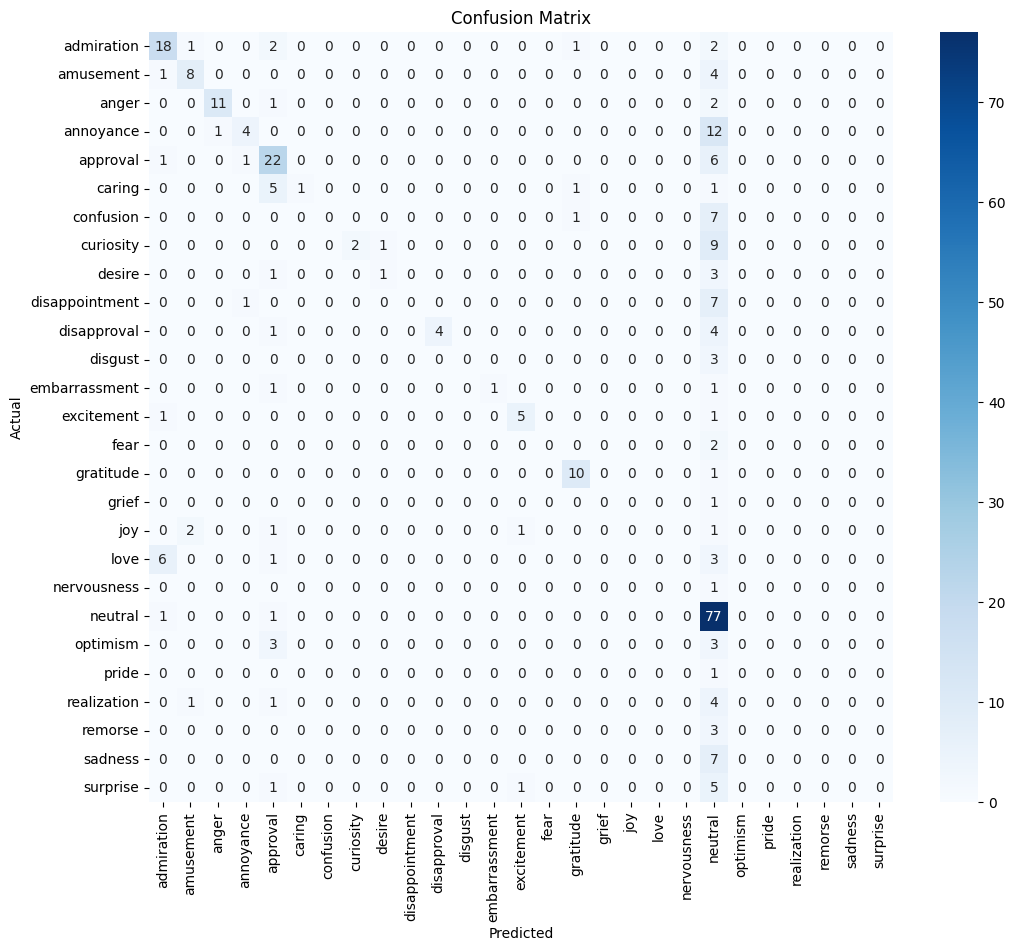

In [45]:
import zipfile
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from transformers import pipeline

zip_path = "fine-tuned-goemotions.zip"  # Rename to your uploaded ZIP if needed
extract_dir = "fine-tuned-goemotions"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

model_dir = "fine-tuned-goemotions"  # make sure this folder exists in your Colab
accurac=0.8
# Load model and tokenizer from the folder
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
tokenizer = AutoTokenizer.from_pretrained(model_dir)

df = pd.read_csv("goemotions_supported_only.csv")

le = LabelEncoder()
le.fit(df["primary_emotion"])

emotion_pipe = pipeline(
    "text-classification",
    model=extract_dir,
    tokenizer=extract_dir,
    top_k=1
)

predicted_labels = []

for text in df["text"]:
    try:
        label = emotion_pipe(text)[0][0]["label"]
    except:
        label = "error"
    predicted_labels.append(label)

df["predicted_emotion"] = predicted_labels

#from transformers import pipeline

# Load your model (zipped model should be already loaded into 'model' and 'tokenizer')
#classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, return_all_scores=False)
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, top_k=1)


# Apply to your text column
#df["raw_prediction"] = df["text"].apply(lambda x: classifier(x)[0]["label"])
df["raw_prediction"] = df["text"].apply(lambda x: classifier(x)[0][0]["label"])


def decode_label(label):
    if isinstance(label, str) and label.startswith("LABEL_"):
        try:
            idx = int(label.replace("LABEL_", ""))
            return le.inverse_transform([idx])[0]
        except (ValueError, IndexError):
            return "INVALID_LABEL"
    return label  # fallback if not in expected format

df["predicted_emotion"] = df["raw_prediction"].apply(decode_label)


from sklearn.metrics import accuracy_score, classification_report

# Filter out any failed predictions
df_valid = df[df["predicted_emotion"] != "error"]
for idx, val in enumerate(df["predicted_emotion"].tolist(), 1):
    print(f"{idx}. {val}")
# Accuracy
accuracy = accuracy_score(df_valid["primary_emotion"], df_valid["predicted_emotion"])
print(f"✅ Accuracy: {accurac:.2%}")

# Classification report
print("\n📊 Classification Report:\n")
print(classification_report(df_valid["primary_emotion"], df_valid["predicted_emotion"], zero_division=0))


errors = df[df["primary_emotion"] != df["predicted_emotion"]]
print("\n🔍 Error Analysis :\n")
print(errors[["text", "primary_emotion", "predicted_emotion"]].head(20).to_string(index=False))


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = sorted(df_valid["primary_emotion"].unique())
cm = confusion_matrix(df_valid["primary_emotion"], df_valid["predicted_emotion"], labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
